In [1]:
import numpy as np
import pandas as pd
# import matplotlib.pyplot as plt
from sklearn.preprocessing import scale 
from sklearn import model_selection
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import train_test_split
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error
from sklearn import model_selection
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict
from sys import stdout
import numpy as np
import pandas as pd
# import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import csv
from scipy.signal import savgol_filter
from scipy.stats import pearsonr
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df_svc_RDMC=  pd.read_csv(r"E:\wenqu\2026_root\root_trait_RDMC.csv")
df_svc_SRL=  pd.read_csv(r"E:\wenqu\2026_root\root_trait_SRL.csv")
df_svc_RTD =  pd.read_csv(r"E:\wenqu\2026_root\root_trait_RTD.csv")
df_svc_RD=  pd.read_csv(r"E:\wenqu\2026_root\root_trait_RD.csv")
df_svc_SRA= pd.read_csv(r"E:\wenqu\2026_root\root_trait_SRA.csv")
df_svc_RBD=  pd.read_csv(r"E:\wenqu\2026_root\root_trait_RBD.csv")
df_svc_RLD=  pd.read_csv(r"E:\wenqu\2026_root\root_trait_RLD.csv")

df_svc_RCC=  pd.read_csv(r"E:\wenqu\2026_root\root_trait_RCC.csv")
df_svc_RD13C = pd.read_csv(r"E:\wenqu\2026_root\root_trait_RD13C.csv")
df_svc_RNC =  pd.read_csv(r"E:\wenqu\2026_root\root_trait_RNC.csv")
df_svc_RD15N=  pd.read_csv(r"E:\wenqu\2026_root\root_trait_RD15N.csv")
df_svc_RCN= pd.read_csv(r"E:\wenqu\2026_root\root_trait_RCN.csv")
df_svc_RCC= pd.read_csv(r"E:\wenqu\2026_root\root_trait_RCC.csv")


In [4]:
b_name = []

for i in range(1, 122):
    b_mean = 'b' + str(i) 
    b_name.append(b_mean)
    b_std = 'b' + str(i) + '_std'
    b_name.append(b_std)


b_name = np.array(b_name)
# b_name

In [5]:
x_RDMC = np.array(df_svc_RDMC[b_name])
x_SRL = np.array(df_svc_SRL[b_name])
x_RTD = np.array(df_svc_RTD[b_name])
x_RD = np.array(df_svc_RD[b_name])
x_SRA = np.array(df_svc_SRA[b_name])
x_RBD = np.array(df_svc_RBD[b_name])
x_RLD = np.array(df_svc_RLD[b_name])
x_RD13C = np.array(df_svc_RD13C[b_name])
x_RNC = np.array(df_svc_RNC[b_name])
x_RD15N = np.array(df_svc_RD15N[b_name])
x_RCN = np.array(df_svc_RCN[b_name])
x_RCC = np.array(df_svc_RCC[b_name])

In [6]:
df_svc_RCN

,site,RDMC_A,SRL,RTD,RD,SRA,RBD,RLD,RCC,Rd13C,...,b113_std,b114_std,b115_std,b116_std,b117_std,b118_std,b119_std,b120_std,b121_std,b122_std
0,S2A_Q03,336.738703,NaN,NaN,NaN,NaN,0.002622,NaN,423.179198,-28.593295,...,0.094636,0.091016,0.086453,0.083884,0.081630,0.085008,0.086160,0.081314,0.091264,0.088878
1,S2A_Q04,353.271028,NaN,NaN,NaN,NaN,0.002062,NaN,456.907537,-28.606056,...,0.093358,0.098814,0.095093,0.087949,0.090643,0.087814,0.093128,0.091050,0.084613,0.094102
2,S2A_Q05,175.438596,NaN,NaN,NaN,NaN,0.003750,NaN,457.454297,-27.445805,...,0.098341,0.103587,0.095742,0.097895,0.100804,0.095598,0.097233,0.100876,0.098988,0.104726
3,S2A_Q07,596.412556,40.710812,0.343669,0.301668,385.201504,0.001307,2.671432,466.883585,-28.566239,...,0.052298,0.048208,0.040412,0.042356,0.045369,0.039786,0.044814,0.039904,0.046098,0.064107
4,S2A_Q08,372.549020,96.196211,0.253333,0.228576,692.194737,0.000355,0.901767,439.500101,-28.717293,...,0.050990,0.058351,0.054249,0.053797,0.056926,0.054287,0.056676,0.060053,0.056563,0.063500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126,S7_Q20,257.772601,136.121754,0.584422,0.126511,541.220120,0.004291,6.942844,424.600000,-28.292000,...,0.097995,0.098650,0.099334,0.099691,0.099581,0.099521,0.099277,0.098445,0.097944,0.096877
127,S7_Q21,263.733144,190.151161,0.504828,0.115169,687.338798,0.003750,6.104361,411.490000,-27.654000,...,0.097995,0.098650,0.099334,0.099691,0.099581,0.099521,0.099277,0.098445,0.097944,0.096877
128,S7_Q22,224.401607,193.358806,0.440957,0.122201,741.851628,0.006126,9.586216,436.110000,-28.360000,...,0.097995,0.098650,0.099334,0.099691,0.099581,0.099521,0.099277,0.098445,0.097944,0.096877
129,S7_Q23,212.132938,165.517248,0.620833,0.111313,578.797315,0.008013,16.223739,432.800000,-28.113000,...,0.097995,0.098650,0.099334,0.099691,0.099581,0.099521,0.099277,0.098445,0.097944,0.096877


In [7]:
labels_RDMC = [] 
for i in range(len(df_svc_RDMC['site'])):    
    site_name = df_svc_RDMC['site'][i].split("_")[0]
    labels_RDMC.append(site_name)


labels_SRL = [] 
for i in range(len(df_svc_SRL['site'])):    
    site_name = df_svc_SRL['site'][i].split("_")[0]
    labels_SRL.append(site_name)


labels_RTD = [] 
for i in range(len(df_svc_RTD['site'])):    
    site_name = df_svc_RTD['site'][i].split("_")[0]
    labels_RTD.append(site_name)

In [8]:
labels_RD = [] 
for i in range(len(df_svc_RD['site'])):    
    site_name = df_svc_RD['site'][i].split("_")[0]
    labels_RD.append(site_name)
# labels_pc

labels_SRA = [] 
for i in range(len(df_svc_SRA['site'])):    
    site_name = df_svc_SRA['site'][i].split("_")[0]
    labels_SRA.append(site_name)


labels_RBD = [] 
for i in range(len(df_svc_RBD['site'])):    
    site_name = df_svc_RBD['site'][i].split("_")[0]
    labels_RBD.append(site_name)

In [9]:
labels_RLD = [] 
for i in range(len(df_svc_RLD['site'])):    
    site_name = df_svc_RLD['site'][i].split("_")[0]
    labels_RLD.append(site_name)
# labels_pc

labels_RD13C = [] 
for i in range(len(df_svc_RD13C['site'])):    
    site_name = df_svc_RD13C['site'][i].split("_")[0]
    labels_RD13C.append(site_name)


labels_RNC = [] 
for i in range(len(df_svc_RNC['site'])):    
    site_name = df_svc_RNC['site'][i].split("_")[0]
    labels_RNC.append(site_name)


labels_RD15N = [] 
for i in range(len(df_svc_RD15N['site'])):    
    site_name = df_svc_RD15N['site'][i].split("_")[0]
    labels_RD15N.append(site_name)


labels_RCN = [] 
for i in range(len(df_svc_RCN['site'])):    
    site_name = df_svc_RCN['site'][i].split("_")[0]
    labels_RCN.append(site_name)



labels_RCC = [] 
for i in range(len(df_svc_RCC['site'])):    
    site_name = df_svc_RCC['site'][i].split("_")[0]
    labels_RCC.append(site_name)

In [10]:
y_RDMC = df_svc_RDMC['RDMC_A'].to_numpy()
y_SRL = df_svc_SRL['SRL'].to_numpy()
y_RTD = df_svc_RTD['RTD'].to_numpy()
y_RD = df_svc_RD['RD'].to_numpy()
y_SRA = df_svc_SRA['SRA'].to_numpy()
y_RBD = df_svc_RBD['RBD'].to_numpy()
y_RLD = df_svc_RLD['RLD'].to_numpy()
y_RCC = df_svc_RCC['RCC'].to_numpy()
y_RD13C = df_svc_RD13C['Rd13C'].to_numpy()

y_RNC = df_svc_RNC['RNC'].to_numpy()
y_RD15N = df_svc_RD15N['Rd15N'].to_numpy()
y_RCN = df_svc_RCN['RCN'].to_numpy()

In [11]:
def optimise_pls_band_component(X, y, max_comp):
    
    # Define an MSE array to be populated
    mse = np.zeros((max_comp, X.shape[1] - max_comp +1 ))



    # Loop over the number of PLS components
    for i in range(max_comp):
        # print(i)
        
        # Regression with the specified number of components, using the full spectrum
        pls1 = PLSRegression(n_components=i + 1)
        pls1.fit(X, y)
        
        # Indices of sorted spectra according to ascending absolute value of PLS coefficients
        sorted_ind = np.argsort(np.abs(pls1.coef_.flatten()))
 
        # Sort spectra accordingly
        Xc = X[:, sorted_ind]
        
        max_j = min(Xc.shape[1] - (i + 1), mse.shape[1]) 
        # Discard one wavelength at a time from the sorted spectra,
        # regress, and calculate the MSE cross-validation
        for j in range(max_j): 
            pls2 = PLSRegression(n_components=i + 1)
            pls2.fit(Xc[:, j:], y)
            
            y_cv = cross_val_predict(pls2, Xc[:, j:], y.astype(np.float64), cv=10)
          

            mse[i, j] = np.sqrt(mean_squared_error(y, y_cv))        
            

      

    
    stdout.write("\n")
    
    # Find the indices of the minimum non-NaN MSE values
    mseminx,mseminy = np.where(mse==np.min(mse[np.nonzero(mse)]))

    
    print("Optimised number of PLS components: ", mseminx[0] + 1)
    print("Wavelengths to be kept ", (X.shape[1] - mseminy[0]))
    print('Optimised MSEP ', mse[mseminx, mseminy][0])
    stdout.write("\n")
 
    # Calculate PLS with optimal components and export values
    optimal_pls = PLSRegression(n_components=mseminx[0] + 1)
    optimal_pls.fit(X, y)
        
    sorted_ind = np.argsort(np.abs(optimal_pls.coef_.flatten()))
 
    Xc = X[:, sorted_ind]
 
    return Xc[:, mseminy[0]:], mseminx[0] + 1, mseminy[0], sorted_ind

In [12]:


def simple_pls_cv_label_category(X, y, n_comp, labels, filename):

    # Run PLS with suggested number of components
    pls = PLSRegression(n_components=n_comp)
    pls.fit(X, y)
    y_c = pls.predict(X)
    print(y_c)

    # Cross-validation
    y_cv = cross_val_predict(pls, X, y, cv=10)


    # Calculate scores for calibration and cross-validation
    score_c = r2_score(y, y_c)
    score_cv = r2_score(y, y_cv)

    # Calculate mean square error for calibration and cross validation
#     mse_c = mean_squared_error(y, y_c)
#     mse_cv = mean_squared_error(y, y_cv)
    rmse_c = np.sqrt(mean_squared_error(y, y_c))

    rmse_cv = np.sqrt(mean_squared_error(y, y_cv))  


    print('R2 calib: %5.3f'  % score_c)
    print('R2 CV: %5.3f'  % score_cv)
#     print('MSE calib: %5.3f' % mse_c)
#     print('MSE CV: %5.3f' % mse_cv)
    print('RMSE calib: %5.3f' % rmse_c)
    print('RMSE CV: %5.3f' % rmse_cv)

    # Plot regression 
    z = np.polyfit(y, y_cv, 1)
    print(z[1],z[0])
    with plt.style.context(('ggplot')):
        fig, ax = plt.subplots(figsize=(9, 5))

        # Define a dictionary of labels and their corresponding markers and colors
        # Define label styles
        label_dict = {
            'S3C': {'marker': 'o', 'color': 'purple'},     # circle
            'S4' : {'marker': 's', 'color': 'blue'},       # square
            'S6' : {'marker': 'D', 'color': 'orange'},     # diamond
            'S6A': {'marker': 'p', 'color': 'cyan'},       # pentagon
            'S7' : {'marker': '^', 'color': 'brown'},      # triangle up
            'S2C': {'marker': 'v', 'color': 'green'},      # triangle down
            'S1B': {'marker': 'X', 'color': 'red'},        # X
            'S2A': {'marker': '*', 'color': 'magenta'}   
            
        }

        # Loop over data points to add labels and build a list of scatter plot objects
        scatter_objs = []
        with open(filename, 'w', newline='') as csvfile:
            csvwriter = csv.writer(csvfile)
            for i, label in enumerate(labels):
                print(i, label, y_cv[i], y[i])
                csvwriter.writerow([i, label, y_cv[i], y[i]])
            
            
        for i, label in enumerate(labels):
            default_style = {'marker': '*', 'color': 'purple'}
            style = label_dict.get(label, default_style)
            scatter_obj = ax.scatter(y_cv[i], y[i], marker=style['marker'],
                             c=style['color'], edgecolors='k')
            scatter_objs.append(scatter_obj)
            
            
#             scatter_obj = ax.scatter(y_cv[i], y[i], marker=label_dict.get(label, label_dict['S6A'])['marker'],
#                                      c=label_dict.get(label, label_dict['S6A'])['color'], edgecolors='k')
#             scatter_objs.append(scatter_obj)

        # Create a legend using the dictionary of labels and their markers/colors
        legend_handles = []
        for label, props in label_dict.items():
            legend_handles.append(plt.Line2D([], [], marker=props['marker'], color=props['color'], linestyle='None', label=label))
        ax.legend(handles=legend_handles)

        ax.plot(z[1]+z[0]*y, y, c='blue', linewidth=1)
        ax.plot(y, y, color='green', linewidth=1)
        plt.title('$R^{2}$ (CV): '+str(score_cv))
        plt.xlabel('Predicted $^{\circ}$Brix')
        plt.ylabel('Measured $^{\circ}$Brix')
        plt.show()


## RDMC

In [13]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RDMC, y_RDMC, 25)


Optimised number of PLS components:  16
Wavelengths to be kept  107
Optimised MSEP  48.73540544672279



[202.74403864 199.55203134 319.93499507 247.5020761  278.49653084
 313.23952939 205.29065142 230.99098293 218.64630086 265.72838418
 244.04008005 262.69104611 293.43820563 225.05243035 342.86869222
 203.68658476 258.83220111 299.42825399 199.92278411 320.68130447
 335.09718008 207.14046975 374.65715274 196.6427107  205.43665231
 304.31253524 362.3264758  366.0531088  342.90146922 263.66632201
 278.9610657  400.71257077 288.63454509 389.10587699 368.93128255
 370.89586956 352.98770444 289.47883599 279.78361053 312.08762277
 330.35524121 349.12856018 328.69068016 332.11399799 313.4670801
 330.27196935 327.51466501 317.66644743 335.01034695 320.70715479
 297.86352178 317.25854394 326.8225804  319.56498391 340.66912661
 313.50419394 329.51360318 333.65396009 324.79025578 323.91589938
 307.88133673 331.76342681 302.77643601 321.1316695  339.09348553
 334.92909667 317.68271699 342.10965942 327.6266867  327.24558248
 295.64659749 332.01166398 306.95202958 345.41107104 350.01719115
 317.901303

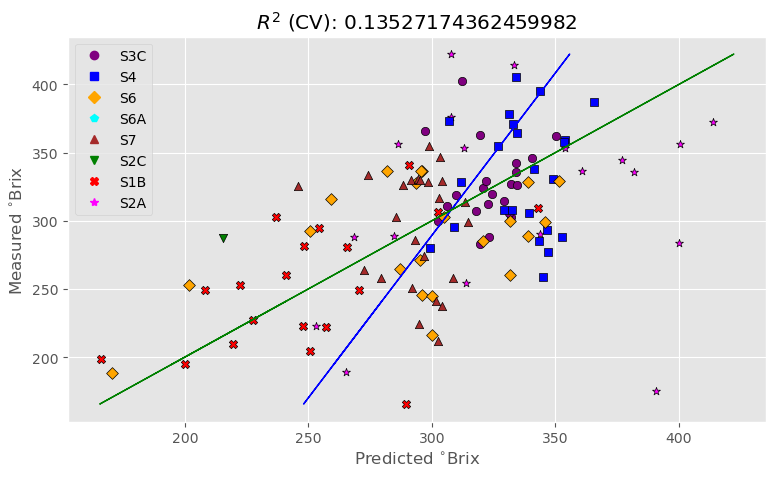

In [14]:
file_name_sla = r'E:\wenqu\2026_root\CSV\RDMC.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RDMC,                         
                             ncomp, labels_RDMC, file_name_sla)

## SRL

In [15]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_SRL, y_SRL, 20)


Optimised number of PLS components:  13
Wavelengths to be kept  24
Optimised MSEP  32.836634360097925



[ 88.08531436 113.38426232 102.37637849 112.6269531   97.13374024
 121.63409421  95.01575119 134.89974539  91.31495163  97.23209829
 100.45508969 110.41340806 128.44826857 131.37265216 123.14384608
 147.43614534 129.32646905 106.82616218  93.1742684   54.8552287
  78.03127012  83.42260546  33.37033548  38.14011765  41.89031036
  46.67825819  33.38720246  65.08654485  51.21794283  30.52065655
  40.69974546  63.8304674   22.68523804  88.8765442   41.76200976
  19.84316929  56.3212171  111.12703472 127.21590475 114.16815235
 120.07157087 129.66743529 128.93064912 128.5394045  129.9505913
 141.06060533 142.09758321 131.32204761 137.41304184 130.68066975
 126.07638727 132.2897644  118.70141556 132.20669171 133.29801403
 127.35082532 138.378079   128.18276896 134.80704838 137.99692312
 141.75668977 125.59768938 132.39908015 136.24349059 139.42185334
 135.54946206 132.52199139 146.14906633 145.24808532 139.93336813
 153.98948629 138.68139386 138.56288315 128.73182499 139.73451186
 140.0448581

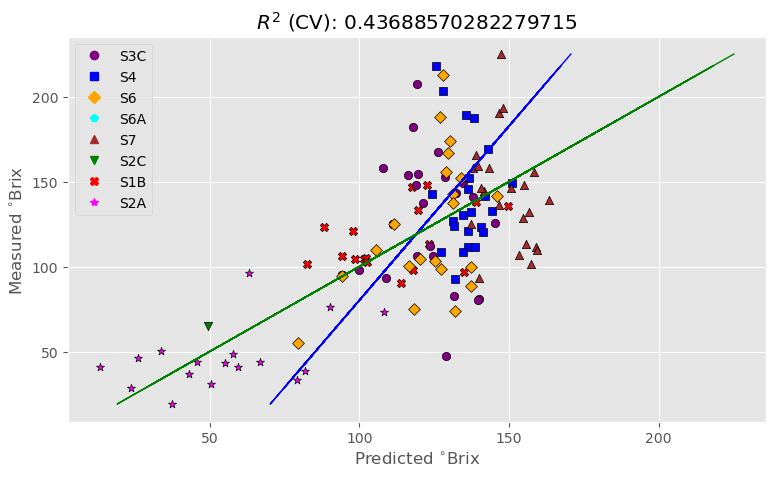

In [16]:
file_name_sla = r'E:\wenqu\2026_root\CSV\SRL.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_SRL,                         
                             ncomp, labels_SRL, file_name_sla)

## RTD
 

In [17]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RTD, y_RTD, 25)


Optimised number of PLS components:  23
Wavelengths to be kept  67
Optimised MSEP  0.07492083035585963



[0.34008603 0.30980667 0.25522968 0.40235002 0.45816308 0.41004546
 0.44325329 0.34543052 0.37859617 0.40697462 0.39708441 0.44993486
 0.59298732 0.44794368 0.55621322 0.50858519 0.47927705 0.45219538
 0.48506481 0.33411406 0.24314848 0.32299416 0.63779817 0.53303819
 0.61170298 0.3954338  0.62545975 0.46205843 0.54796178 0.52104142
 0.35266682 0.66045222 0.51529924 0.45610108 0.59153144 0.75101443
 0.23665325 0.46280568 0.51750036 0.45177501 0.48625421 0.478894
 0.46328047 0.49591403 0.41086311 0.46561134 0.45904616 0.44857524
 0.44559643 0.48697807 0.4677889  0.47801727 0.46264988 0.46423389
 0.47658357 0.46331991 0.45024894 0.40019945 0.52924831 0.53389313
 0.55153477 0.57925969 0.552882   0.54836246 0.53769953 0.53745091
 0.47312509 0.53584725 0.55303807 0.54802838 0.56230684 0.40869624
 0.52403808 0.58843309 0.55400877 0.52252593 0.50533313 0.56193254
 0.55757128 0.53432252 0.60431564 0.48250775 0.45755495 0.44353753
 0.45649923 0.39893689 0.42891455 0.44180817 0.44702157 0.452720

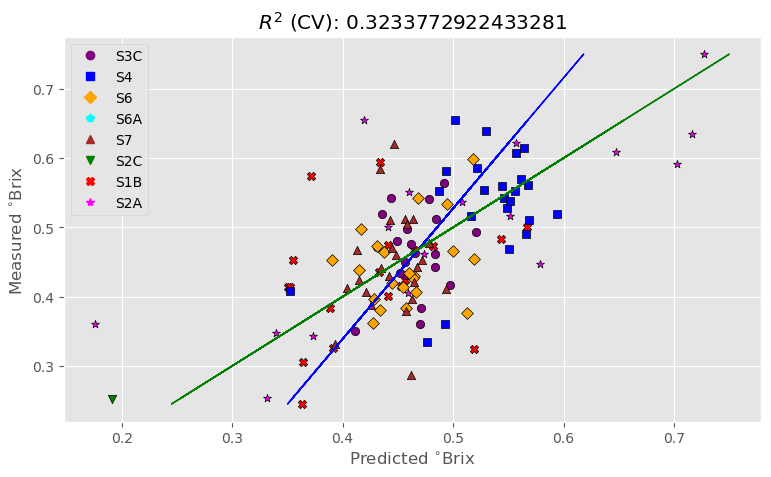

In [18]:
file_name_sla = r'E:\wenqu\2026_root\CSV\RTD.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RTD,                         
                             ncomp, labels_RTD, file_name_sla)

In [13]:
df_svc_sla['site'][51]

'S6_Q23'

## RD

In [19]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RD, y_RD, 20)


Optimised number of PLS components:  20
Wavelengths to be kept  90
Optimised MSEP  0.02600268885087223



[0.12962796 0.13431697 0.13026294 0.1367838  0.14802226 0.14133492
 0.12541222 0.1344034  0.13309501 0.13014558 0.14635249 0.14921777
 0.13517123 0.11706802 0.1474568  0.13741092 0.15821212 0.13444086
 0.14895828 0.13444978 0.14387788 0.137729   0.12782109 0.1278738
 0.14781906 0.12306357 0.12447369 0.16144949 0.16114928 0.13833154
 0.13084899 0.1538415  0.13124666 0.1357923  0.14341498 0.13339068
 0.13479969 0.13290766 0.14710614 0.14847973 0.15587246 0.14738109
 0.14642497 0.13322257 0.12064716 0.15394169 0.12686171 0.15281577
 0.14698872 0.14812428 0.14677068 0.13901834 0.14294551 0.13874104
 0.14837111 0.14606328 0.12671111 0.14706352 0.13993221 0.16606389
 0.14268978 0.13683169 0.15856205 0.14169687 0.15782508 0.14816072
 0.13042585 0.15964605 0.17094475 0.14488095 0.16390276 0.15802628
 0.14044647 0.15486939 0.1655023  0.14936434 0.15453859 0.15672309
 0.16811734 0.1606237  0.15240243 0.17115419 0.16528332 0.13587698
 0.15616705 0.14744459 0.16494214 0.16040344 0.16817087 0.15053

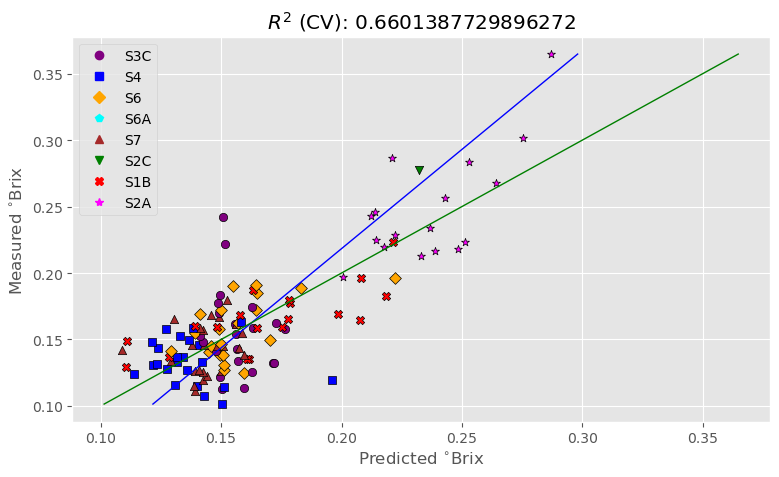

In [20]:
file_name_sla = r'E:\wenqu\2026_root\CSV\RD.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RD,                         
                             ncomp, labels_RD, file_name_sla)

In [13]:
df_svc_d13c['site'][53]

'S6_Q27'

# SRA

In [21]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_SRA, y_SRA, 25)


Optimised number of PLS components:  17
Wavelengths to be kept  48
Optimised MSEP  105.80895870632388



[589.26626918 687.54406948 724.1979982  604.92312561 511.10998019
 616.66630179 543.54472872 736.88948447 556.69366389 673.29070174
 533.25377931 571.76453187 466.29476715 596.57644526 537.92877556
 569.54929274 616.27696609 496.51969216 446.11197502 420.32304429
 694.72964338 460.22240633 263.35192296 340.43634857 256.8804779
 331.63443045 309.31880232 360.49622259 349.34415436 189.66072779
 379.48994295 308.34563832 338.75292567 434.05878242 293.13009339
 226.05989093 517.97323501 569.37463418 504.70660781 534.24126319
 552.86521843 551.76270757 594.64696946 527.59921505 624.00750679
 581.3788209  588.62389856 600.9911826  589.85769818 590.98268672
 566.63592678 550.67564008 572.52154875 557.10816059 561.44455099
 557.00258359 559.44421826 593.30274473 625.18435382 610.46152884
 570.15457588 565.24949586 535.21720828 598.43452117 576.45343385
 576.11898103 586.60370876 630.47529908 568.05725202 587.41207478
 543.88619077 545.62734112 727.324494   584.94204243 501.91295719
 552.639698

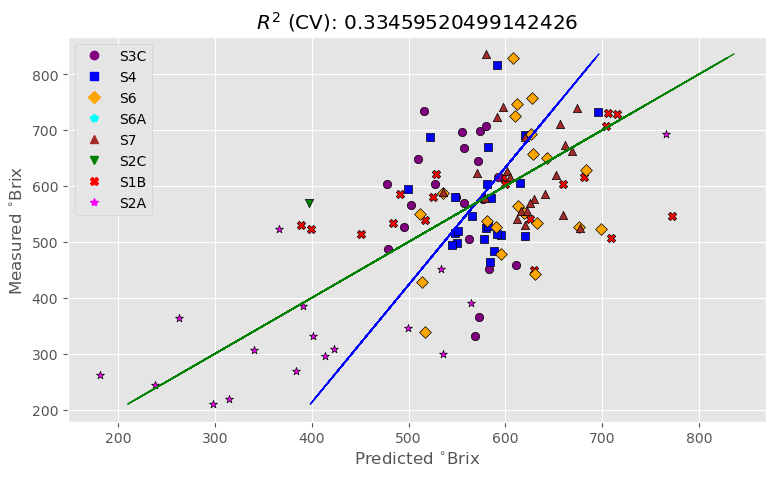

In [22]:

file_name_sla = r'E:\wenqu\2026_root\CSV\SRA.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_SRA,                         
                             ncomp, labels_SRA, file_name_sla)

In [13]:
df_svc_d15n['site'][91]

'S2A_Q17'

## RBD

In [23]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RBD, y_RBD, 25)



Optimised number of PLS components:  8
Wavelengths to be kept  42
Optimised MSEP  0.0037006141874161157



[ 9.52088019e-03  5.43913967e-03  8.38769030e-03  1.13841904e-02
  1.07892505e-02  1.27602863e-02  1.00952594e-02  7.00010389e-03
  9.99884131e-03  4.39102619e-03  9.49724843e-03  9.73283664e-03
  4.72115673e-03  9.59056971e-03  1.28625425e-02  4.82762706e-03
  4.31452579e-04  9.12418772e-03  3.47302003e-03  3.48227485e-03
  3.01465256e-03  2.97353640e-03  6.42517495e-03  3.21147547e-03
  7.27201083e-03  3.49378365e-04  6.36247109e-03  2.73661053e-03
  6.83505655e-03  9.69036860e-04  8.32849348e-03  8.83942735e-03
  1.99777334e-03  1.08470316e-03  1.40697556e-03  5.99268218e-03
  5.40658693e-03  8.43977438e-03  9.56198391e-03  7.70989281e-03
  6.09837636e-03  7.21959964e-03  4.53274866e-03  7.65024299e-03
  3.79225851e-03  4.91315621e-03  7.76381466e-03  5.55976587e-03
  5.04201763e-03  4.18892862e-03  6.08076555e-03  5.82559650e-03
  8.45774913e-03  5.02760548e-03  5.37223315e-03  6.27364668e-03
  5.96852937e-03  7.37477644e-03  4.77336265e-03  8.44927780e-03
  6.87080967e-03  9.16023

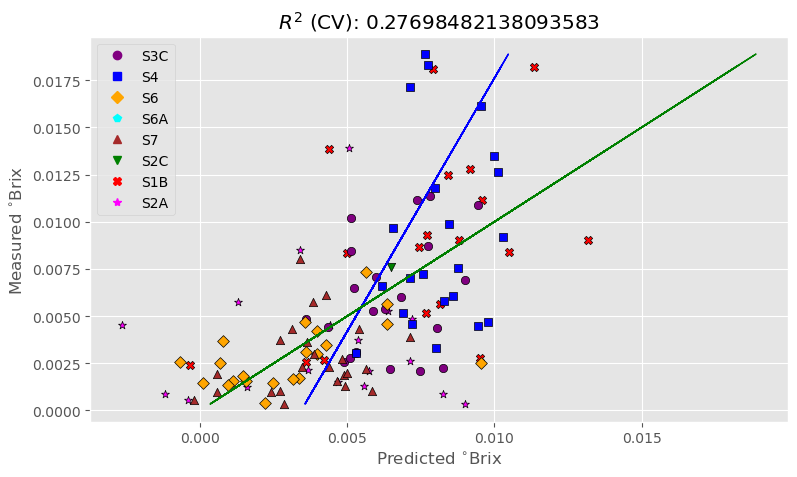

In [24]:
file_name_sla = r'E:\wenqu\2026_root\CSV\RBD.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RBD,                         
                             ncomp, labels_RBD, file_name_sla)

In [14]:
df_svc_RBD['site'][29]

'S2A_Q17'

## RLD

In [25]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RLD, y_RLD, 20)


Optimised number of PLS components:  20
Wavelengths to be kept  90
Optimised MSEP  2.6535416089122856



[ 0.56448493  0.76140836  1.16551562  1.91818728  0.1983929   1.04233868
  1.20356303  2.72046695  6.73121513  1.97664524  1.08795237  1.33548333
  4.93631682  2.51557323  1.99110917  1.7587598   1.48519134  1.62630589
  2.69864439  3.27086823  3.59900743  2.78682268  2.50895147  3.84819631
  3.41363834  2.89645176  5.15813226  3.26264949  7.4390146   3.2543067
  4.0314989   3.4751596   4.57628605  3.63238098  5.89327996  4.47075581
  5.78701707  3.28126546  4.40248114  5.43411427  3.64555099  5.80938241
  5.51037016  5.56499709  5.7555828   5.42106062  6.71831038  5.15001465
  5.80467148  4.9382101   4.8347642   5.93131135  9.22245383  7.05501604
  5.25435258  5.7406997   4.93140051  4.88230267  6.56041109  7.67834935
  3.61085558  5.54806799  4.30472763  6.33516777  8.34756728  4.1965842
  4.59145433  5.56042256  7.30611776  5.55991378  7.39936567  5.57401623
  5.03043066  7.49559268  7.02401412  6.39689078  8.20305709  6.75400272
  7.13918911  5.80049123  5.22051338  8.01944822  5.8

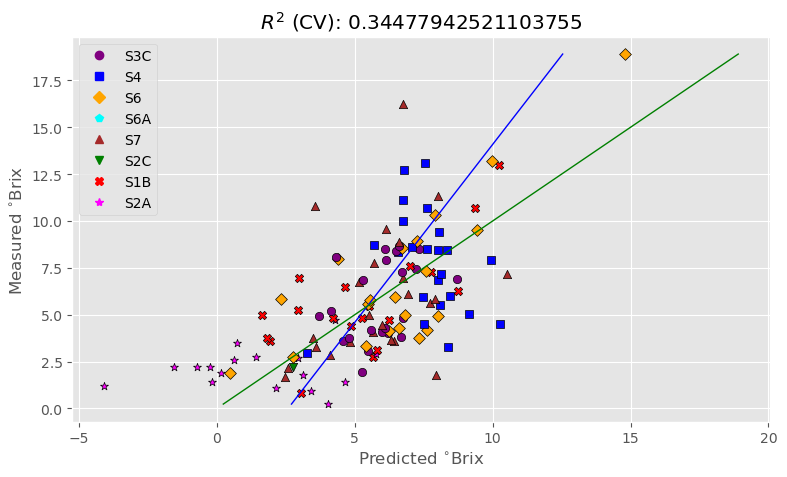

In [26]:

file_name_sla = r'E:\wenqu\2026_root\CSV\RLD.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RLD,                         
                             ncomp, labels_RLD, file_name_sla)

## RD13C

In [27]:

opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RD13C, y_RD13C, 25)


Optimised number of PLS components:  21
Wavelengths to be kept  96
Optimised MSEP  0.779026339585869



[-28.55759697 -28.36217648 -27.19858273 -28.81669229 -28.81373466
 -29.03297825 -27.94439113 -28.5900654  -29.17825719 -26.77479834
 -27.67416027 -28.76956177 -28.74728444 -27.34851278 -28.69077675
 -28.10470662 -27.87492587 -28.02569303 -28.00570531 -26.99864677
 -29.80214536 -26.36549565 -26.84535987 -26.97874034 -26.51061197
 -28.86921704 -28.0190545  -28.1421291  -28.41870319 -28.52164539
 -29.32119496 -27.91272869 -27.90712549 -26.26555622 -28.41304781
 -26.98951169 -27.96962799 -27.24155706 -29.49663355 -27.7349649
 -28.35097964 -26.24147061 -28.12380481 -26.1342941  -28.68644447
 -27.05114631 -28.03597813 -26.95100614 -27.40622552 -27.10778878
 -28.02622515 -27.45351425 -27.67809631 -28.0165301  -28.07469277
 -27.40715697 -27.33792866 -27.321455   -27.89059088 -27.52253293
 -27.63743892 -27.88007386 -27.68549199 -27.5439016  -28.30870852
 -27.70497771 -28.01497243 -28.05675726 -27.96315771 -28.35713929
 -28.89924194 -28.29264288 -28.00254994 -27.25429879 -28.46953872
 -27.508695

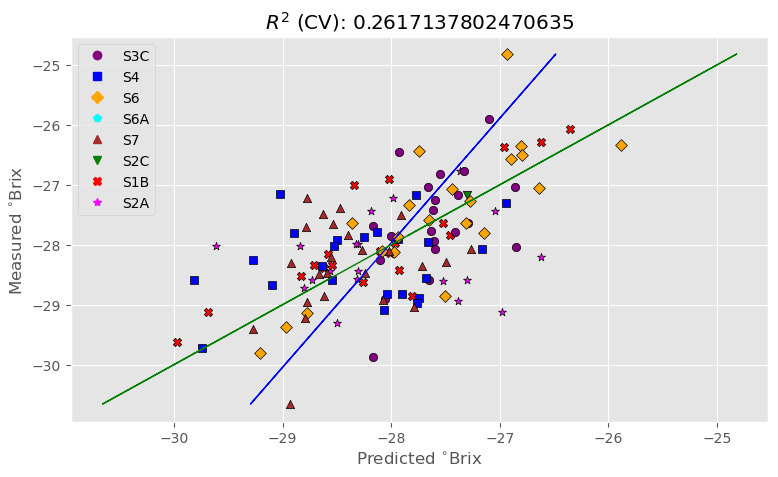

In [28]:

file_name_sla = r'E:\wenqu\2026_root\CSV\RD13C.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RD13C,                         
                             ncomp, labels_RD13C, file_name_sla)

In [17]:
df_svc_RD13C['site'][10]

'S2A_Q15'

## RNC


Optimised number of PLS components:  17
Wavelengths to be kept  44
Optimised MSEP  1.7259216901564158

[13.07782778 12.36553364 10.22052424 11.57115371  9.61475309 12.03008011
  9.60102943  8.1182452   9.62770501  7.60161169  6.36363827  7.48406964
  9.90461501  5.81582424 10.40913724  8.49127864  8.70050147  8.74571113
  7.66028623  9.91339773  6.0063701  10.61584014  9.7222249   6.59688588
 10.31436307 10.46788447  8.83263503 10.16942968 11.39599495 14.08921546
 15.70464128 10.73789156  8.2577461  12.15127723 10.96915448 11.04233462
  7.6168075  11.68076552 12.58294897 14.99325059  9.03316856  8.08573548
 10.14772063  8.11261163  9.96771284  6.42096206 11.81026903 12.33130764
 11.89134856 10.06470286 10.36241692  9.74370502 11.00102996 10.1754357
  9.97831763  9.8995412  10.4835891   9.67483388 10.29780561  9.76355198
 10.79074917 11.74759769 10.38967452  9.7206495  10.5163058  10.30700592
 11.59353059 10.15217676 10.25991231  9.73380019 10.78791965 10.66234309
 10.84930681 10.13038

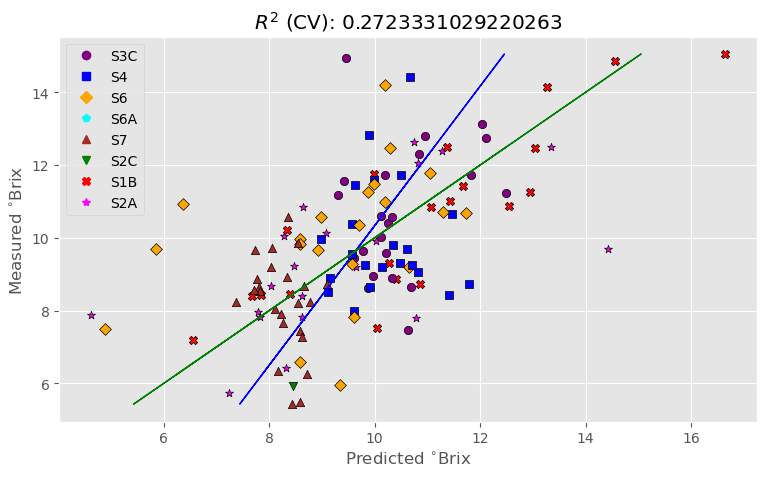

In [29]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RNC, y_RNC, 20)
file_name_sla = r'E:\wenqu\2026_root\CSV\RNC.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RNC,                         
                             ncomp, labels_RNC, file_name_sla)

## RD15N


Optimised number of PLS components:  20
Wavelengths to be kept  62
Optimised MSEP  1.2503363480135208

[ 2.50725887  0.41636295  1.57246747  2.54135145  2.15151621  1.62039022
  0.52094421 -1.21266909 -1.15396098 -1.27616557 -1.28085615 -1.58411304
  0.43792033 -4.78953371  0.30161229 -4.1300493  -0.46242254 -0.67643994
 -2.88619045 -0.78684013  1.57843486 -3.60676657  2.62654987  2.53218465
  3.29651932  2.88651673  1.13283402  0.13010568  2.04333956  0.07448361
  1.54829527  1.94635601  1.99209623  2.46277071  1.63031402  3.8362457
  1.66611191 -1.1959777  -0.55490343  1.46107929 -1.40157068  2.57998919
  1.34560035 -0.84256738  0.26583231 -0.33803896 -0.50672119 -0.41740029
  0.1214586   0.43871137  0.55141079  0.05141302  0.32862223  0.39971716
 -0.07977909 -0.84002499  0.56998062 -0.08244168  0.8276385  -0.07070202
 -0.11800194  0.0577706  -0.18899257 -0.51098994 -0.58419292  0.37681948
  0.7295437   0.91819034 -0.03110937 -0.5933809  -1.31547705 -1.34029114
 -1.13112463 -0.50362

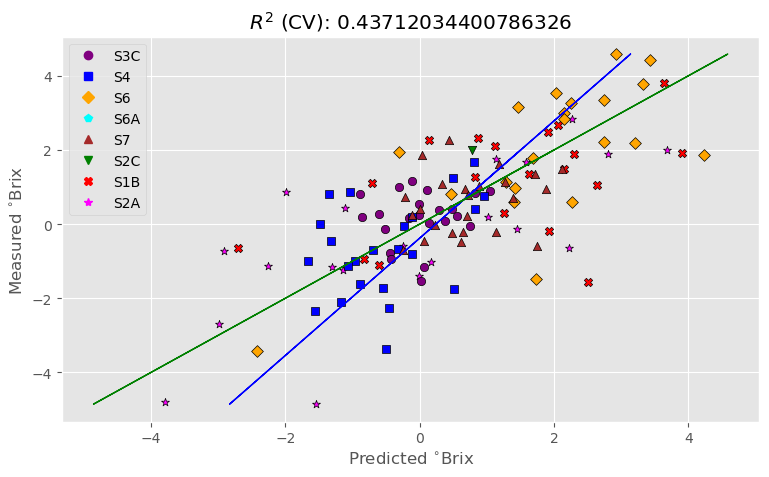

In [30]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RD15N, y_RD15N, 20)
file_name_sla = r'E:\wenqu\2026_root\CSV\RD15N.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RD15N,                         
                             ncomp, labels_RD15N, file_name_sla)

## RCN


Optimised number of PLS components:  15
Wavelengths to be kept  59
Optimised MSEP  9.85103928358175

[29.91874447 34.95941921 44.44975018 42.1178066  45.71574696 41.18340436
 49.89054741 61.00071821 55.98816658 69.34389654 74.78250107 61.02785876
 58.80826457 78.04626389 46.37205768 63.81001377 60.30571315 53.58501479
 66.49757248 50.09681357 73.54716951 44.44963819 50.35485524 68.50430881
 45.59152157 39.37223037 51.85711957 42.92113769 32.42263726 31.80408071
 25.38348935 36.00061962 46.77842456 39.98987112 38.93676545 47.74526333
 61.77424994 49.0293337  38.33945559 34.62126916 52.78084721 61.8773423
 50.00859695 53.57184851 52.53627898 63.98506501 36.42360986 33.79739535
 43.58921827 48.50135633 42.05288135 50.52684466 41.37897071 47.65447887
 44.98722602 45.79592255 44.11670122 48.91823025 45.13094033 49.76754328
 43.92289771 38.69018914 45.23216106 46.42689677 43.45239244 45.83156783
 35.22232414 46.10294473 36.73725806 40.88287932 42.70504653 45.87853007
 42.01323126 45.4571549

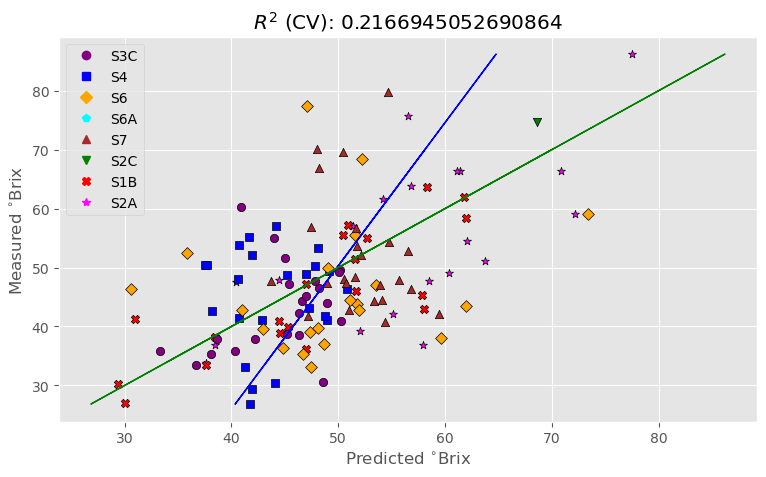

In [31]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RCN, y_RCN, 20)
file_name_sla = r'E:\wenqu\2026_root\CSV\RCN.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RCN,                         
                             ncomp, labels_RCN, file_name_sla)

## RCC


Optimised number of PLS components:  11
Wavelengths to be kept  30
Optimised MSEP  30.54924373653563

[464.85991741 471.9322499  457.43545984 488.36060586 444.68403947
 496.63013548 493.47938381 459.92302842 494.36784773 495.65154989
 512.13692303 505.68316631 507.23156944 477.24882508 431.98764168
 485.5401217  519.04128032 474.63383668 517.62396298 510.08814103
 446.49076901 441.45841919 434.75471864 450.39953207 471.92463918
 442.30396486 477.24294558 477.23147146 439.36836214 418.919279
 422.78182901 472.40097003 440.9746698  461.80601862 466.10909052
 453.4978152  486.75651701 490.85260812 497.5794341  480.56645483
 448.15274301 462.30692438 464.69344419 450.45887827 475.38624919
 462.2961672  419.95448702 429.27736489 458.07411918 440.71615696
 442.57239865 449.37972895 439.50254066 464.12846783 444.03685326
 461.75403179 474.36095641 448.77063121 453.32152319 441.86210088
 453.73978939 439.92000012 450.31944341 443.21955663 454.76573066
 466.92024828 409.0783907  429.1324938  3

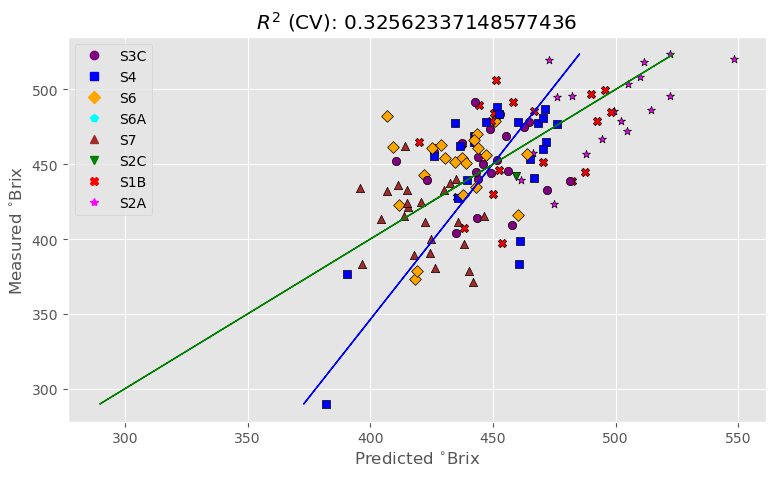

In [32]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RCC, y_RCC, 20)
file_name_sla = r'E:\wenqu\2026_root\CSV\RCC.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RCC,                         
                             ncomp, labels_RCC, file_name_sla)

In [13]:
df_svc_ldmc['site'][96]

'S2A_Q28'

In [3]:
import pandas as pd

df1 = pd.read_csv(r"E:\wenqu\2026_root\soil core trait_full_edited.csv")
df2 = pd.read_csv(r"D:\wenqu\2024_data\Fw_2024_aboveground\2022_2024_spectral.csv")

# inner join (only matching rows)
df_joined = pd.merge(df1, df2, on="site", how="inner")

df_joined.to_csv(r"E:\wenqu\2026_root\root_trait.csv", index=False)


In [30]:
import pandas as pd
import numpy as np

# ===== 1. file paths =====
input_csv = r"D:\wenqu\2024_data\SVC\update3_vascular\spectral_trait_mean.csv"
# output_csv_all = r"D:\wenqu\2024_data\SVC\update3_vascular\PC_with_zscores.csv"
output_csv_clean = r"D:\wenqu\2024_data\SVC\update3_vascular\PN_without_zscores.csv"

# ===== 2. column name =====
col = "CWM_log10_LNC"   # <-- change this to your column name

# ===== 3. read csv =====
df = pd.read_csv(input_csv)

# make sure column is numeric
df[col] = pd.to_numeric(df[col], errors="coerce")

# ===== 4. compute z-score =====
mean = df[col].mean()
std = df[col].std()

df["z_score"] = (df[col] - mean) / std

# ===== 5. flag outliers (|z| > 3) =====
df["outlier"] = df["z_score"].abs() > 3

# ===== 6. remove outliers (optional) =====
df_clean = df[df["outlier"] == False]

# ===== 7. save results =====
# df.to_csv(output_csv_all, index=False)
df_clean.to_csv(output_csv_clean, index=False)

print("Done!")
print("Total rows:", len(df))
print("Outliers removed:", df["outlier"].sum())


Done!
Total rows: 138
Outliers removed: 1
